In [4]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

In [5]:
tf.__version__

'2.19.1'

In [6]:
# load and preprocess CIFAR-10 data
# https://www.tensorflow.org/datasets/catalog/cifar10
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of 6d958be074577803d12ecdefd02955f39262c83c16fe9348329d7fe0b5c001ce so we will re-download the data.
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 725s 4us/step  


In [7]:
# Normalize pixel values
train_images, test_images = train_images / 255.0, test_images / 255.0

In [12]:
# define a CNN model
model = models.Sequential([
    # Convolutional Layer 1: 32 filters, 3x3 kernel, ReLU activation
    layers.Conv2D(32, (3, 3), activation = "relu", input_shape = (32, 32, 3)),
    # Max Pooling: 2x2 window
    layers.MaxPool2D((2, 2)),

    # Convolutional Layer 2: 64 filters, 3x3 kernel
    layers.Conv2D(64, (3, 3), activation = "relu"),
    layers.MaxPool2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation = "relu"),

    # Flatten the feature maps
    layers.Flatten(),
    
    # Fully Connected Layer: 64 neurons
    layers.Dense(64, activation = "relu"),
    
    # Output Layer: 10 classes
    layers.Dense(10)
])

# compile the model
model.compile(optimizer = "adam",
             loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
             metrics = ["accuracy"])

In [16]:
# train the model
history = model.fit(train_images, train_labels, epochs = 10, validation_data = (test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8115 - loss: 0.5315 - val_accuracy: 0.7031 - val_loss: 0.9193
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.8245 - loss: 0.4906 - val_accuracy: 0.7061 - val_loss: 0.9286
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.8394 - loss: 0.4528 - val_accuracy: 0.7125 - val_loss: 0.9193
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.8473 - loss: 0.4289 - val_accuracy: 0.6968 - val_loss: 1.0212
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.8611 - loss: 0.3976 - val_accuracy: 0.7036 - val_loss: 1.0301
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.8693 - loss: 0.3677 - val_accuracy: 0.7016 - val_loss: 1.0639
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.8777 - loss: 0.3468 - val_accuracy: 0.7061 - val_loss: 1.0561
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.8866 -

In [17]:
# evaluate the model
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose = 2)
print(f"Test Accuracy: {test_acc:.2f}")

313/313 - 1s - 4ms/step - accuracy: 0.7021 - loss: 1.1952
Test Accuracy: 0.70


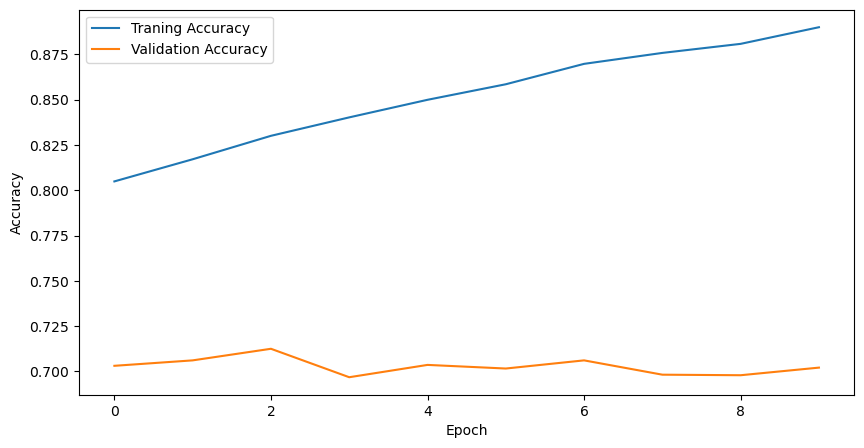

In [19]:
import matplotlib.pyplot as plt

# plot training history
plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Traning Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()